<a href="https://colab.research.google.com/github/ThAlvesM/Kmean_2026-1/blob/Test%2FNovo_dataset/Kmean_2026-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

----------------------------------------
# Seção 1: Introdução
----------------------------------------
● 1.1. Contextualização: Recapitule brevemente o problema de negócio ou pesquisa que você se propôs a resolver no Projeto 1.

● 1.2. Objetivo: Qual pergunta específica você está tentando responder com esta
análise?

● 1.3. Descrição dos Dados: Apresente o dataset, sua fonte e um dicionário de dados
(descrição das colunas/variáveis mais importantes).

*   List item
*   List item



-----------------------------------------------
#Seção 2: Análise Exploratória de Dados (EDA)
-----------------------------------------------
● 2.1. Carregamento e Limpeza dos Dados: Importe os dados e mostre os primeiros
passos de verificação (ex: .info(), .describe(), .isnull().sum()). Descreva como tratou
dados faltantes, duplicados ou inconsistentes.

● 2.2. Análise Univariada: Explore as variáveis individualmente. Use gráficos
(histogramas, boxplots, etc) e métricas para entender a distribuição e as características
de cada variável relevante. Comente suas observações.

● 2.3. Análise Bivariada e Multivariada: Investigue a relação entre as variáveis. Use
gráficos (scatter plots, heatmaps de correlação) e tabelas para identificar padrões,
tendências e correlações.

● 2.4. Insights da Eda: Faça um resumo do que você aprendeu nesta fase. A análise
confirmou sua hipótese inicial? Surgiram novas perguntas? Quais variáveis parecem
ser mais promissoras para a modelagem?

In [ ]:
install.packages("GGally")
library(GGally)
library(ggplot2)
library(tidyr)
library(dplyr)


Installing package into ‘/home/idhac/R/x86_64-pc-linux-gnu-library/4.5’
(as ‘lib’ is unspecified)

also installing the dependencies ‘isoband’, ‘tibble’, ‘tidyselect’, ‘forcats’, ‘patchwork’, ‘purrr’, ‘stringr’, ‘hms’, ‘cpp11’, ‘ggplot2’, ‘dplyr’, ‘ggstats’, ‘progress’, ‘RColorBrewer’, ‘S7’, ‘scales’, ‘tidyr’


Warning message in install.packages("GGally"):
“installation of package ‘forcats’ had non-zero exit status”


In [ ]:
install.packages("fastDummies")
library(fastDummies)

In [ ]:
dataset <- read.csv ("segmentation_ata.csv", header = TRUE)
#Fazer alguma verificação aqui no meio
print("Dataset Instalado com Sucesso")

In [ ]:
info_colun_num <- function(c){
  cat("Tipo:", typeof(c), "| NAs:", sum(is.na(c) | c == ""), "| Únicos:", n_distinct(c), "\n")
  cat(paste("5 primeiros elementos:",
  c[1], " - ", c[2], " - ",c[3], " - ",c[4], " - ",c[5], "\n"))

  if (is.numeric(c)) {
    cat(paste("Mínimo:", round(min(c), 2), "\t"))
    cat(paste("1ºQuart:", round(quantile(c, probs = 0.25), 2), "\t"))
    cat(paste("Média:", round(mean(c),2), "\t"))
    cat(paste("3ºQuart:", round(quantile(c, probs = 0.75), 2), "\t"))
    cat(paste("Máximo:", round(max(c), 2), "\n"))
    cat(paste("Desvio Padrão:", round(sd(c), 2),"\t"))
    cat(paste("Mediana", round(median(c), 2),"\n"))

  } else {
      c_filtrado <- c[c != "" & !is.na(c)]
      cat(paste("Máximo caracteres:", max(nchar(c_filtrado)), "\t"))
      cat(paste("Mínimo caracteres:", min(nchar(c_filtrado)), "\n"))

      tab_abs <- table(c)
      names(dimnames(tab_abs)) <- "Frequncia Absoluta"
      print(tab_abs)


      tab_rel <- prop.table(table(c)) * 100
      names(dimnames(tab_rel)) <- "Frequencia Relativa"
      print(tab_rel)

  }
}

In [ ]:
#Coluna Id
cat("Id\n")
info_colun_num(dataset$ID)
cat("-------------------------------------------------\n")
#Coluna Sexo
cat("Sex\n")
info_colun_num(dataset$Sex)
cat("-------------------------------------------------\n")
#Coluna Idade
cat("Marital status\n")
info_colun_num(dataset$Age)
cat("-------------------------------------------------\n")
#Coluna Salario Anual
cat("\n")
info_colun_num(dataset$Education)
cat("-------------------------------------------------\n")
#Coluna Score de Gasto
cat("Spending.Score..1.100.\n")
info_colun_num(dataset$Income)
cat("-------------------------------------------------\n")
#Coluna Profissao
cat("Profession\n")
info_colun_num(dataset$Occupation)
cat("-------------------------------------------------\n")
#Coluna Experiencia de Trabalho
cat("Work Experience\n")
info_colun_num(dataset$Settlement.size)
cat("-------------------------------------------------\n")
#Coluna Familiares
# cat("Family Size\n")
# info_colun_num(dataset$Family.Size)
# cat("-------------------------------------------------\n")

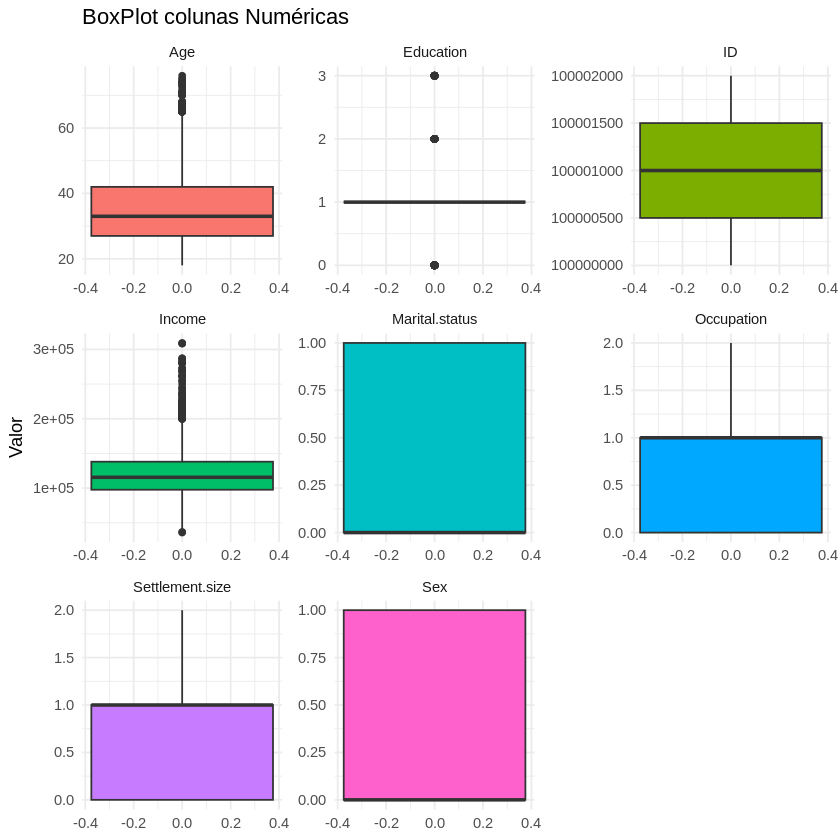

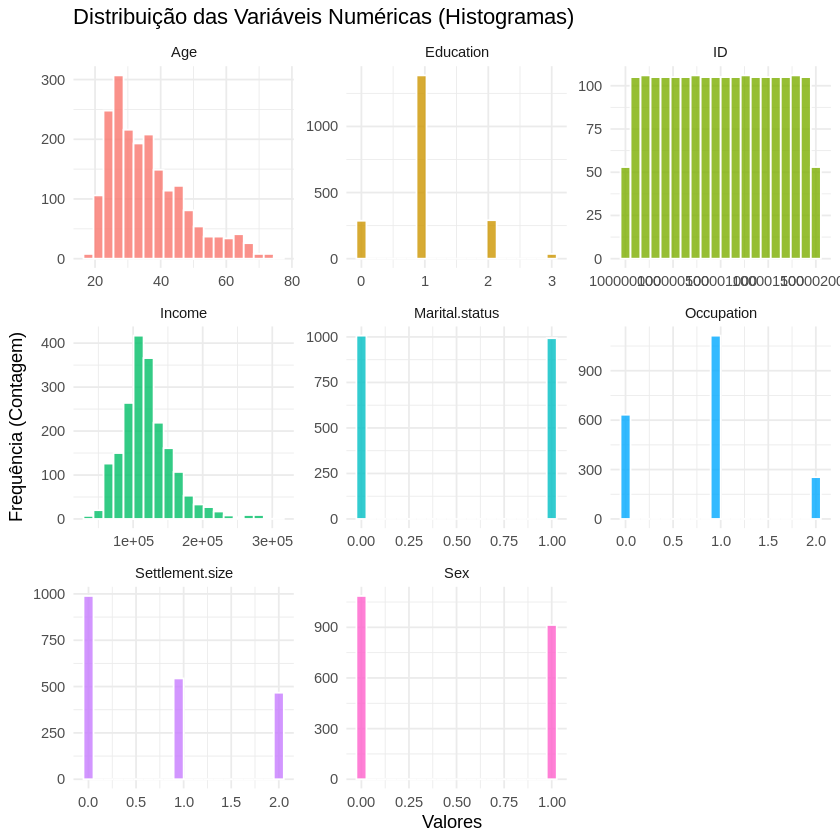

In [25]:
dados_longo <- dataset %>%
  select(where(is.numeric)) %>%
  pivot_longer(cols = everything(), names_to = "Variavel", values_to = "Valor")

ggplot(dados_longo, aes(y = Valor, fill = Variavel)) +
  geom_boxplot() +
  facet_wrap(~Variavel, scales = "free") +
  theme_minimal() +
  theme(legend.position = "none") +
  labs(title = "BoxPlot colunas Numéricas")

dados_longo <- dataset %>%
  select(where(is.numeric)) %>%
  pivot_longer(cols = everything(), names_to = "Variavel", values_to = "Valor")

ggplot(dados_longo, aes(x = Valor, fill = Variavel)) +
  geom_histogram(bins = 20, color = "white", alpha = 0.8) +
  facet_wrap(~Variavel, scales = "free") +
  theme_minimal() +
  theme(legend.position = "none") +
  labs(
    title = "Distribuição das Variáveis Numéricas (Histogramas)",
    x = "Valores",
    y = "Frequência (Contagem)"
  )

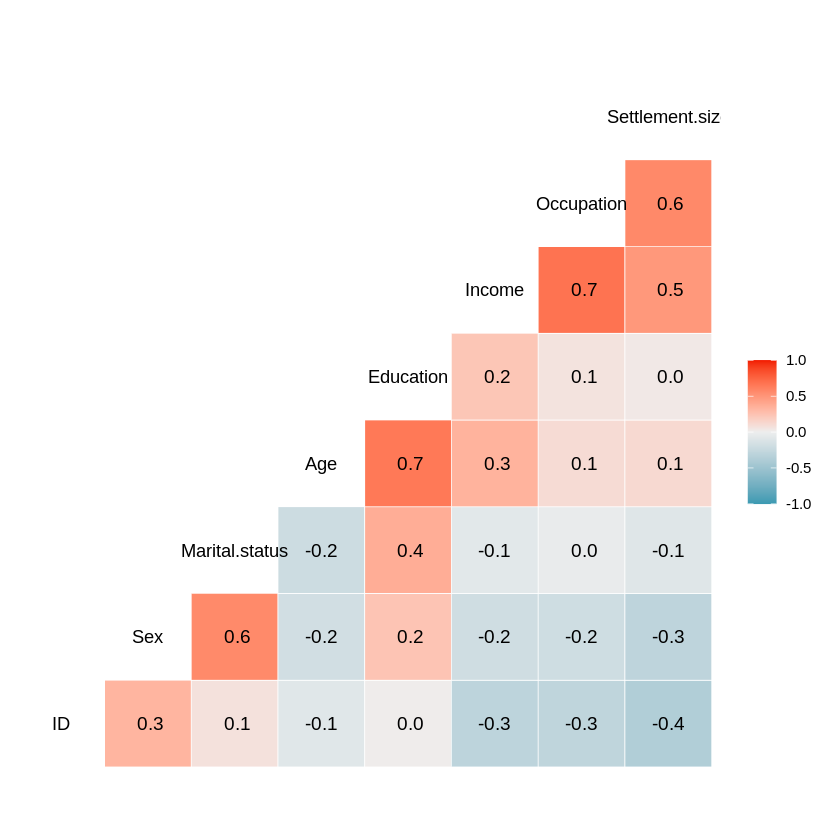

In [26]:
dataset_numerico <- dataset[, sapply(dataset, is.numeric)]
ggcorr(dataset_numerico, label=T)

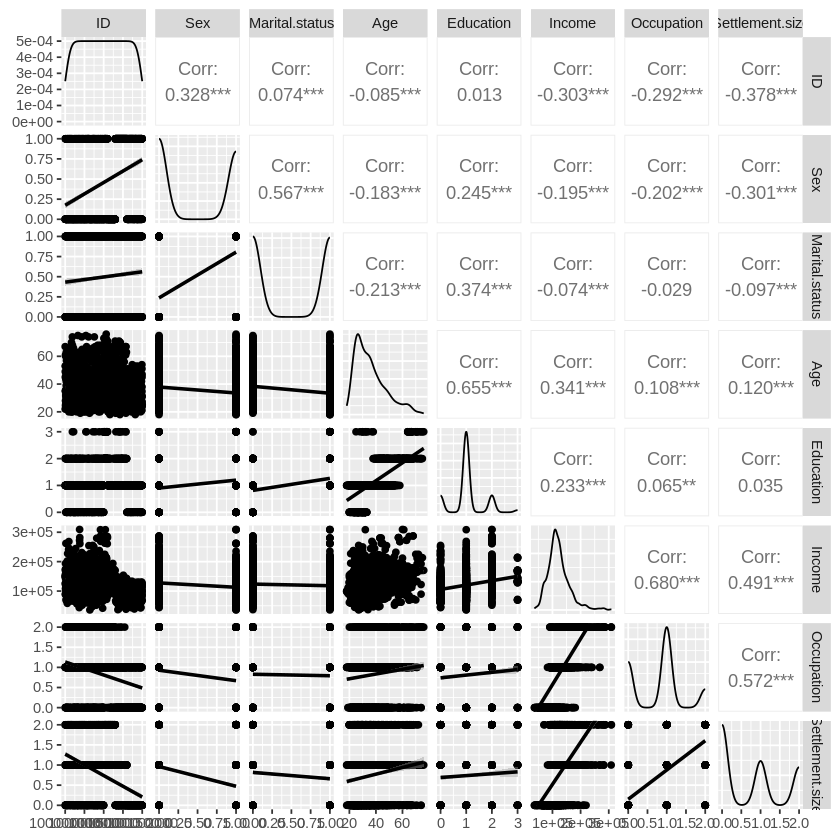

In [27]:
ggpairs(dataset, lower = list(continuous = "smooth"))

In [28]:
cat("Total de linhas duplicadas no dataset:", sum(duplicated(dataset)), "\n")
cat("Total de Ids duplicados no dataset:", sum(duplicated(dataset$CustomerID)))

Total de linhas duplicadas no dataset: 0 
Total de Ids duplicados no dataset: 0

In [11]:
dataset$Profession[dataset$Profession == ""] <- "Sem Profissão"
#maiores de 18 anos
dataset_18 <- dataset[which(dataset$Age >= 18), ]
cat("Outliers removidos:", nrow(dataset) - nrow(dataset_18), "linhas.\n")
#idade minima pela lei
dataset_filtrado <- dataset_18[which((dataset_18$Age - dataset_18$Work.Experience) >= 14), ]
cat("Outliers removidos:", nrow(dataset_18) - nrow(dataset_filtrado), "linhas.\n")

Outliers removidos: 332 linhas.
Outliers removidos: 43 linhas.


In [30]:
summary(dataset)

       ID             Sex        Marital.status        Age       
 Min.   :1e+08   Min.   :0.000   Min.   :0.0000   Min.   :18.00  
 1st Qu.:1e+08   1st Qu.:0.000   1st Qu.:0.0000   1st Qu.:27.00  
 Median :1e+08   Median :0.000   Median :0.0000   Median :33.00  
 Mean   :1e+08   Mean   :0.457   Mean   :0.4965   Mean   :35.91  
 3rd Qu.:1e+08   3rd Qu.:1.000   3rd Qu.:1.0000   3rd Qu.:42.00  
 Max.   :1e+08   Max.   :1.000   Max.   :1.0000   Max.   :76.00  
   Education         Income         Occupation     Settlement.size
 Min.   :0.000   Min.   : 35832   Min.   :0.0000   Min.   :0.000  
 1st Qu.:1.000   1st Qu.: 97663   1st Qu.:0.0000   1st Qu.:0.000  
 Median :1.000   Median :115548   Median :1.0000   Median :1.000  
 Mean   :1.038   Mean   :120954   Mean   :0.8105   Mean   :0.739  
 3rd Qu.:1.000   3rd Qu.:138072   3rd Qu.:1.0000   3rd Qu.:1.000  
 Max.   :3.000   Max.   :309364   Max.   :2.0000   Max.   :2.000  

-----------------------------------------------
#Seção 3: Validação Estatística (Teste de Hipóteses)
-----------------------------------------------
● 3.1. Definição das Hipóteses: Declare formalmente a Hipótese Nula e a Hipótese
Alternativa. As hipóteses devem estar relacionadas aos padrões identificados na EDA.

● 3.2. Escolha a Execução do Teste: Utilize o teste adequado para o seu tema (Teste t,
ANOVA, Qui-quadrado, Teste de Correlação de Pearson, etc.).

● 3.3. Interpretação do p-valor: Com base em um nível de significância (ex: 5%),
determine se há evidências para rejeitar a hipótese nula e valide se o padrão encontrado
na EDA é estatisticamente significante.

-----------------------------------------------
#Seção 4: Pré-processamento e Aplicação da Técnica
-----------------------------------------------
● 4.1. Preparação dos Dados para o Modelo: Descreva e execute os passos necessários
para preparar os dados para a sua técnica específica (ex: normalização/padronização
para K-Means, criação de variáveis dummy para regressão, etc.).

● 4.2. Modelagem: Aplicação do algoritmo do seu tema. Explique a escolha de
parâmetros, se houver.

In [35]:
df = dataset[,!(names(dataset) %in% c("ID"))]


# dataset_preparado <- dummy_cols(
#   dataset_f,
#   select_columns = c("Gender","Profession"),
#   remove_selected_columns = TRUE
# )

head(df)

dataset_final<- as.data.frame(scale(df))
head(dataset_final)

,Sex,Marital.status,Age,Education,Income,Occupation,Settlement.size
,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,0,0,67,2,124670,1,2
2,1,1,22,1,150773,1,2
3,0,0,49,1,89210,0,0
4,0,0,45,1,171565,1,1
5,0,0,53,1,149031,1,1
6,0,0,35,1,144848,0,0


,Sex,Marital.status,Age,Education,Income,Occupation,Settlement.size
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-0.9171695,-0.992776,2.65295099,1.60392184,0.09749923,0.2967488,1.5519379
2,1.0897659,1.006773,-1.18683527,-0.06335658,0.78245869,0.2967488,1.5519379
3,-0.9171695,-0.992776,1.11703649,-0.06335658,-0.83299391,-1.2692080,-0.9095021
4,-0.9171695,-0.992776,0.77572215,-0.06335658,1.32805410,0.2967488,0.3212179
5,-0.9171695,-0.992776,1.45835082,-0.06335658,0.73674749,0.2967488,0.3212179
6,-0.9171695,-0.992776,-0.07756368,-0.06335658,0.62698289,-1.2692080,-0.9095021


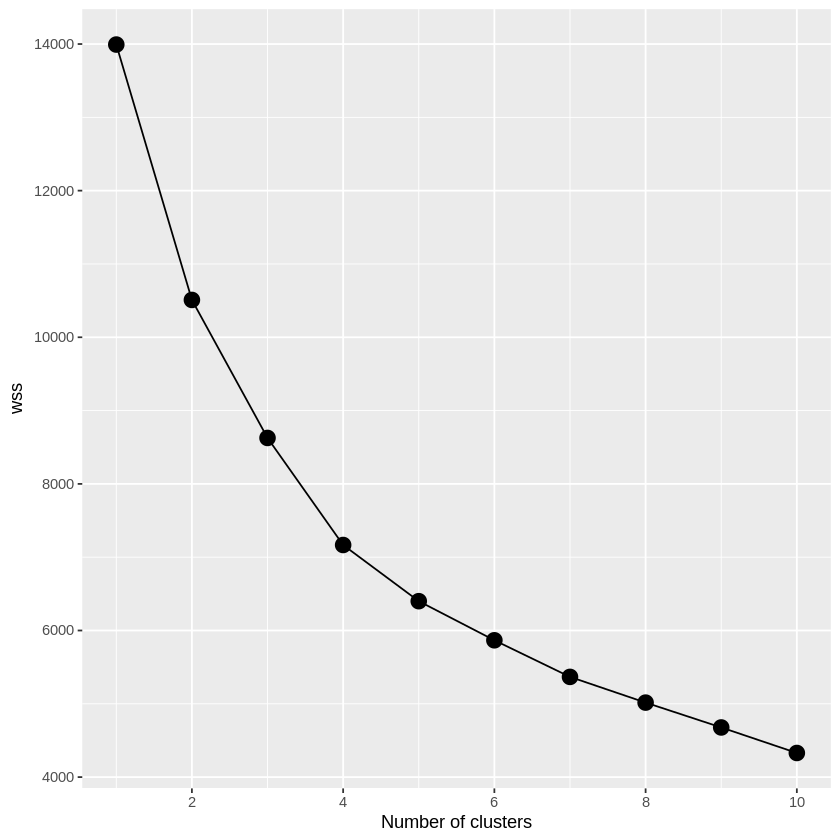

In [40]:
n_clusters <- 10

wss <- numeric(n_clusters)

set.seed(123)

for (i in 1:n_clusters) {
  km.out <- kmeans(dataset_final, centers = i, nstart = 20)
  wss[i] <- km.out$tot.withinss
}

wss_df <- tibble(clusters = 1:n_clusters, wss = wss)

scree_plot <- ggplot(wss_df, aes(x = clusters, y = wss, group = 1)) +
    geom_point(size = 4)+
    geom_line() +
    scale_x_continuous(breaks = c(2, 4, 6, 8, 10)) +
    xlab('Number of clusters')
scree_plot


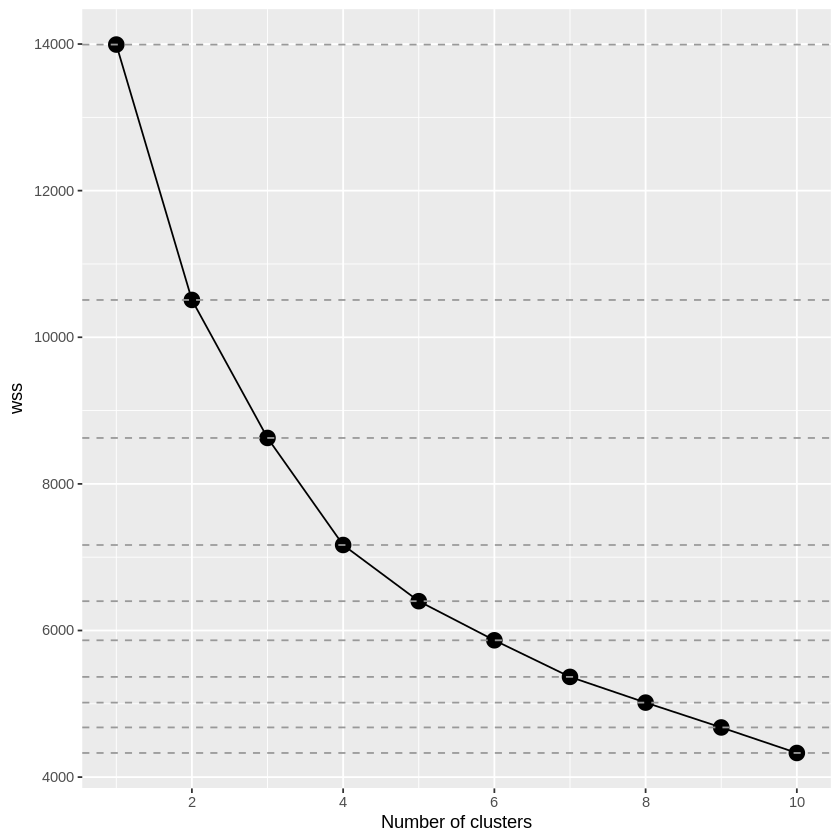

In [41]:
scree_plot +
  geom_hline(
    yintercept = wss,
    linetype = 'dashed',
    color = 'gray60',
    linewidth = 0.5
  )

In [39]:
km.out <- kmeans(dataset_final, centers = 4, nstart = 20)
print(km.out)

K-means clustering with 4 clusters of sizes 570, 263, 705, 462

Cluster means:
          Sex Marital.status         Age   Education     Income Occupation
1 -0.85731349     -0.6454860 -0.02337255 -0.50796416  0.5317359  0.7225792
2  0.09011369      0.3909422  1.68902999  1.81946354  0.9809802  0.4991919
3  0.79655407      1.0011004 -0.59268205  0.05016025 -0.3987344 -0.2763247
4 -0.20909486     -0.9538238 -0.02825041 -0.48558943 -0.6060162 -0.7540014
  Settlement.size
1       0.9646469
2       0.4569247
3      -0.3892828
4      -0.8562241

Clustering vector:
   [1] 2 3 4 1 1 4 1 1 2 1 3 3 3 4 3 3 4 1 2 1 1 1 4 1 1 4 4 2 1 2 1 1 1 4 3 4 1
  [38] 1 1 1 1 3 4 1 2 3 4 3 4 3 4 1 1 4 2 4 1 3 3 3 1 1 2 1 3 1 3 3 1 3 3 4 1 3
  [75] 1 2 1 1 4 3 2 1 3 2 4 3 3 1 1 1 1 1 3 1 1 2 2 1 1 1 4 4 3 1 3 1 1 1 3 3 1
 [112] 3 1 3 1 1 3 3 3 1 3 2 4 2 3 1 4 1 1 3 3 1 4 1 3 3 1 2 1 3 3 3 1 1 3 1 3 2
 [149] 1 1 4 1 1 1 1 3 1 3 1 4 1 3 1 2 1 1 3 3 3 1 4 3 1 4 1 2 2 1 1 2 1 1 4 1 1
 [186] 1 2 4 3 3 1 4 1 3 1 1 3 

-----------------------------------------------
#Seção 5: Resultados e Interpretação
-----------------------------------------------
● 5.1. Apresentação dos Resultados: Mostre a saída do seu modelo de forma clara.
Pode ser uma tabela com coeficientes, uma visualização dos clusters, uma imagem da
árvore de decisão, etc.

● 5.2. Análise Crítica dos Resultados: Esta é a parte mais importante. Traduza a
saída técnica em uma explicação clara e objetiva.
  
○ Exemplo para K-Means: "O modelo identificou 3 clusters. O Cluster 1, que
chamamos de 'Clientes Econômicos', é caracterizado por... O Cluster 2,
'Clientes Premium', por sua vez..."
  
○ Exemplo para Regressão Linear: "O coeficiente para a variável 'área_m2' foi
de 850. Isso sugere que, mantendo as outras variáveis constantes, cada metro
quadrado adicional está associado a um aumento de R$850 no preço do
aluguel."

-----------------------------------------------
#Seção 6: Conclusão
-----------------------------------------------
● 6.1. Resumo dos Insights: Sintetize as principais descobertas do seu projeto.
Responda diretamente à pergunta que você se propôs a investigar na introdução.

● 6.2. Recomendações Práticas: Com base nos seus achados, o que você recomendaria
para uma empresa ou área de estudo? Proponha 1 ou 2 ações concretas.

● 6.3. Limitações e Próximos Passos: Nenhum projeto é perfeito. Discuta as limitações
da sua análise (ex: poucos dados, variáveis faltantes, simplicidade do modelo).